# DistilBERT custom PTQ and codebook quantization from 2 to 8 bits

This notebook evaluates the same trained DistilBERT SST-2 classifier under full-model custom PTQ and scalar codebook weight quantization for every bit width from 2 through 8. Every accuracy uses all 872 labelled SST-2 development examples. Rank-one biases and normalization parameters remain FP32; all 40 eligible rank-two-or-higher kernels/embeddings are quantized. Activations remain FP32 and no fake quantization or retraining is used.

The notebook is resumable. Each completed row and prediction vector is saved immediately. Compatible W4/W8 results from notebooks 21 and 18 are reused by default.

In [1]:
from pathlib import Path
import gc, json, platform, sys, time
import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists(): raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits,
    dequantize_tensor, reconstruct_codebook_tensor,
)
print(f"Python: {sys.version.split()[0]}; TensorFlow: {tf.__version__}; Keras: {keras.__version__}")
from src.models import DISTILBERT_BASE_EN_UNCASED_PRESET, build_distilbert_text_preprocessor

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7; TensorFlow: 2.20.0; Keras: 3.14.1


## 1. Configuration

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "sst2" / "SST-2"
DEV_PATH = DATA_DIR / "dev.tsv"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "distilbert_sst2_ptq" / "distilbert_sst2_fp32.keras"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "distilbert_ptq_codebook_bit_sweep"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
RESULT_PATH = OUTPUT_DIR / "distilbert_ptq_codebook_2_to_8_bit.csv"
W4_W8_PATH = PROJECT_ROOT / "artifacts" / "distilbert_4bit_stratified_sensitivity" / "full_model_w4_vs_w8.csv"
LOCAL_VOCAB_PATH = Path.home() / ".cache" / "kagglehub" / "models" / "keras" / "distil_bert" / "keras" / "distil_bert_base_en_uncased" / "3" / "assets" / "tokenizer" / "vocabulary.txt"

BIT_WIDTHS = list(range(2, 9))
METHODS = ("ptq", "codebook")
SEQUENCE_LENGTH, NUM_EXAMPLES, BATCH_SIZE = 128, 872, 32
PTQ_PER_CHANNEL = True
CODEBOOK_VECTOR_DIM, CODEBOOK_DTYPE = 1, np.float32
CODEBOOK_ITERATIONS, CODEBOOK_MAX_SAMPLES = 30, 100_000
RANDOM_SEED, FORCE_RECOMPUTE = 42, False
REUSE_EXISTING_W4_W8 = True

for path in (MODEL_PATH, DEV_PATH):
    if not path.exists(): raise FileNotFoundError(path)
for directory in (OUTPUT_DIR, PREDICTION_DIR): directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print(f"Bits: {BIT_WIDTHS}; methods: {METHODS}; evaluation examples: {NUM_EXAMPLES}")

Bits: [2, 3, 4, 5, 6, 7, 8]; methods: ('ptq', 'codebook'); evaluation examples: 872


## 2. Complete SST-2 evaluation split and trained checkpoint

In [3]:
dev_frame = pd.read_csv(DEV_PATH, sep="\t")
test_texts = dev_frame.sentence.astype(str).to_numpy(); test_labels = dev_frame.label.astype(np.int32).to_numpy()
assert len(test_texts) == len(test_labels) == NUM_EXAMPLES
if LOCAL_VOCAB_PATH.exists():
    tokenizer = keras_hub.models.DistilBertTokenizer(str(LOCAL_VOCAB_PATH), lowercase=True)
    preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor(tokenizer, sequence_length=SEQUENCE_LENGTH)
else: preprocessor = build_distilbert_text_preprocessor(sequence_length=SEQUENCE_LENGTH)
def tokenize_texts(texts, batch_size=256):
    chunks={"token_ids":[],"padding_mask":[]}
    for start in range(0,len(texts),batch_size):
        encoded=preprocessor(tf.constant(texts[start:start+batch_size]))
        for name in chunks: chunks[name].append(encoded[name].numpy().astype(np.int32))
    return {name:np.concatenate(values) for name,values in chunks.items()}
test_inputs=tokenize_texts(test_texts)

model=keras.models.load_model(MODEL_PATH,compile=False); evaluation_model=keras.models.load_model(MODEL_PATH,compile=False)
baseline_weights=[weight.numpy() for weight in model.weights]; fp32_parameter_bytes=int(sum(value.nbytes for value in baseline_weights))
rows=[]
for weight_index,(weight,value) in enumerate(zip(model.weights,baseline_weights)):
    name=getattr(weight,"path",weight.name)
    if np.issubdtype(value.dtype,np.floating) and value.ndim>=2 and (name.endswith("/kernel") or name.endswith("/embeddings")):
        rows.append({"weight_index":weight_index,"tensor":name,"parameter_count":int(value.size),"fp32_bytes":int(value.nbytes)})
coverage=pd.DataFrame(rows); assert len(coverage)==40,len(coverage)
candidate_names=coverage.tensor.tolist(); candidate_by_name=coverage.set_index("tensor").to_dict(orient="index")
print(f"Eligible tensors: {len(coverage)}; FP32 size: {fp32_parameter_bytes/1024**2:.2f} MiB")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Eligible tensors: 40; FP32 size: 255.41 MiB


## 3. Quantization, storage, and resumable inference helpers

In [4]:
def slice_inputs(inputs,start,stop): return {name:value[start:stop] for name,value in inputs.items()}
def predict_labels(weights):
    evaluation_model.set_weights(weights); outputs=[]
    for start in range(0,NUM_EXAMPLES,BATCH_SIZE):
        logits=evaluation_model(slice_inputs(test_inputs,start,start+BATCH_SIZE),training=False).numpy(); outputs.append(np.argmax(logits,axis=1))
    return np.concatenate(outputs).astype(np.int16)
def prediction_path(method,bits): return PREDICTION_DIR / f"{method}_w{bits}_predictions.npz"
def packed_ptq_bytes(tensor,bits): return int((tensor.values.size*bits+7)//8 + np.asarray(tensor.scale).nbytes)

def quantize_and_reconstruct(method,bits):
    names=set(candidate_names)
    if method=="ptq":
        result=custom_ptq_n_bits(model,num_bits=bits,per_channel=PTQ_PER_CHANNEL,included_tensor_names=names)["weights"]
        tensors=result.tensors; rebuild=dequantize_tensor; storage=lambda tensor:packed_ptq_bytes(tensor,bits)
    elif method=="codebook":
        result=codebook_vectorize_model_n_bits(model,num_bits=bits,vector_dim=CODEBOOK_VECTOR_DIM,mode="vector",
            included_tensor_names=names,codebook_dtype=CODEBOOK_DTYPE,max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
            kmeans_iterations=CODEBOOK_ITERATIONS,seed=RANDOM_SEED)
        tensors=result.tensors; rebuild=reconstruct_codebook_tensor; storage=lambda tensor:int(tensor.estimated_compressed_size_bytes)
    else: raise ValueError(method)
    weights=baseline_weights.copy(); quantized_bytes=fp32_parameter_bytes; error2=signal=0.0
    for tensor in tensors:
        info=candidate_by_name[tensor.name]; original=baseline_weights[info["weight_index"]]; reconstructed=rebuild(tensor).astype(original.dtype)
        weights[info["weight_index"]]=reconstructed; quantized_bytes += storage(tensor)-info["fp32_bytes"]
        delta=original.astype(np.float64)-reconstructed.astype(np.float64); error2+=float(np.sum(delta**2)); signal+=float(np.sum(original.astype(np.float64)**2))
    if len(tensors)!=len(candidate_names): raise RuntimeError(f"Expected {len(candidate_names)} tensors, got {len(tensors)}")
    return weights,int(quantized_bytes),error2/signal

def load_saved_rows():
    if FORCE_RECOMPUTE or not RESULT_PATH.exists(): return []
    return pd.read_csv(RESULT_PATH).to_dict(orient="records")
def save_rows(rows): pd.DataFrame(rows).sort_values(["method","num_bits"]).to_csv(RESULT_PATH,index=False)

## 4. FP32 baseline and compatible W4/W8 seed rows

In [5]:
fp32_path=PREDICTION_DIR / "fp32_predictions.npz"
if fp32_path.exists() and not FORCE_RECOMPUTE:
    with np.load(fp32_path) as cached: fp32_predictions=cached["predictions"]
else:
    fp32_predictions=predict_labels(baseline_weights); np.savez_compressed(fp32_path,predictions=fp32_predictions)
fp32_accuracy=float(np.mean(fp32_predictions==test_labels)); print(f"FP32 accuracy: {fp32_accuracy*100:.4f}%")

sweep_rows=load_saved_rows()
if REUSE_EXISTING_W4_W8 and not sweep_rows and W4_W8_PATH.exists() and not FORCE_RECOMPUTE:
    existing=pd.read_csv(W4_W8_PATH)
    for row in existing.itertuples(index=False):
        sweep_rows.append({"method":row.method_family,"num_bits":int(row.bit_width),"codebook_size":2**int(row.bit_width) if row.method_family=="codebook" else np.nan,
            "quantized_tensors":len(candidate_names),"correct_predictions":int(row.correct_predictions),"evaluation_examples":int(row.evaluation_examples),
            "accuracy_percent":float(row.accuracy_percent),"drop_from_fp32_pp":float(row.accuracy_degradation_pp),
            "prediction_disagreement_percent":float(row.prediction_disagreement_percent),"parameter_bytes":int(round(row.parameter_mib*1024**2)),
            "parameter_mib":float(row.parameter_mib),"compression_ratio_vs_fp32":float(row.compression_ratio_vs_fp32),
            "memory_reduction_percent":float(row.memory_reduction_percent),"weight_nmse":np.nan,"quantization_seconds":np.nan,"evaluation_seconds":np.nan,"source":"reused_w4_w8"})
    save_rows(sweep_rows); print("Seeded compatible W4/W8 rows from notebook 21 artifacts.")
display(pd.DataFrame(sweep_rows).sort_values(["method","num_bits"]) if sweep_rows else pd.DataFrame())

FP32 accuracy: 88.4174%
Seeded compatible W4/W8 rows from notebook 21 artifacts.


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,evaluation_examples,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,weight_nmse,quantization_seconds,evaluation_seconds,source
0,codebook,4,16.0,40,770,872,88.302752,0.114679,3.325688,33697800,32.136726,7.947701,87.417745,NaN,NaN,NaN,reused_w4_w8
1,codebook,8,256.0,40,768,872,88.073394,0.344037,1.490826,67182600,64.070320,3.986449,74.915021,NaN,NaN,NaN,reused_w4_w8
2,ptq,4,NaN,40,776,872,88.990826,-0.573394,2.637615,33819664,32.252945,7.919063,87.372243,NaN,NaN,NaN,reused_w4_w8
3,ptq,8,NaN,40,771,872,88.417431,0.000000,0.229358,67266064,64.149918,3.981503,74.883857,NaN,NaN,NaN,reused_w4_w8


## 5. Run every missing PTQ/codebook bit width

In [6]:
completed={(str(row["method"]),int(row["num_bits"])) for row in sweep_rows}
for bits in BIT_WIDTHS:
    for method in METHODS:
        key=(method,bits)
        if key in completed and not FORCE_RECOMPUTE:
            print(f"Skipping saved {method} W{bits}"); continue
        print(f"Running {method} W{bits}..."); start=time.perf_counter()
        weights,parameter_bytes,weight_nmse=quantize_and_reconstruct(method,bits); quantization_seconds=time.perf_counter()-start
        start=time.perf_counter(); predictions=predict_labels(weights); evaluation_seconds=time.perf_counter()-start
        np.savez_compressed(prediction_path(method,bits),predictions=predictions)
        accuracy=float(np.mean(predictions==test_labels)); row={"method":method,"num_bits":bits,"codebook_size":2**bits if method=="codebook" else np.nan,
            "quantized_tensors":len(candidate_names),"correct_predictions":int(np.sum(predictions==test_labels)),"evaluation_examples":NUM_EXAMPLES,
            "accuracy_percent":accuracy*100,"drop_from_fp32_pp":(fp32_accuracy-accuracy)*100,
            "prediction_disagreement_percent":float(np.mean(predictions!=fp32_predictions)*100),"parameter_bytes":parameter_bytes,
            "parameter_mib":parameter_bytes/1024**2,"compression_ratio_vs_fp32":fp32_parameter_bytes/parameter_bytes,
            "memory_reduction_percent":(1-parameter_bytes/fp32_parameter_bytes)*100,"weight_nmse":weight_nmse,
            "quantization_seconds":quantization_seconds,"evaluation_seconds":evaluation_seconds,"source":"computed"}
        sweep_rows=[old for old in sweep_rows if (str(old["method"]),int(old["num_bits"]))!=key]+[row]; save_rows(sweep_rows); completed.add(key)
        print(f"  accuracy={accuracy*100:.2f}% compression={row['compression_ratio_vs_fp32']:.2f}x")
        del weights,predictions; gc.collect()
sweep=pd.DataFrame(sweep_rows).sort_values(["method","num_bits"]); assert len(sweep)==14; display(sweep)

Running ptq W2...
  accuracy=51.03% compression=15.67x
Running codebook W2...
  accuracy=78.33% compression=15.78x
Running ptq W3...
  accuracy=82.91% compression=10.52x
Running codebook W3...
  accuracy=86.24% compression=10.57x
Skipping saved ptq W4
Skipping saved codebook W4
Running ptq W5...
  accuracy=88.19% compression=6.35x
Running codebook W5...
  accuracy=88.19% compression=6.37x
Running ptq W6...
  accuracy=88.07% compression=5.30x
Running codebook W6...
  accuracy=88.07% compression=5.31x
Running ptq W7...
  accuracy=88.30% compression=4.55x
Running codebook W7...
  accuracy=88.42% compression=4.55x
Skipping saved ptq W8
Skipping saved codebook W8


,method,num_bits,codebook_size,quantized_tensors,correct_predictions,evaluation_examples,accuracy_percent,drop_from_fp32_pp,prediction_disagreement_percent,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,weight_nmse,quantization_seconds,evaluation_seconds,source
5,codebook,2,4.0,40,683,872,78.325688,10.091743,24.082569,16972680,16.186409,15.779479,93.662655,0.119946,12.365514,43.398329,computed
7,codebook,3,8.0,40,752,872,86.238532,2.178899,6.077982,25334920,24.161263,10.571182,90.540320,0.039498,14.295431,46.069068,computed
0,codebook,4,16.0,40,770,872,88.302752,0.114679,3.325688,33697800,32.136726,7.947701,87.417745,NaN,NaN,NaN,reused_w4_w8
9,codebook,5,32.0,40,769,872,88.188073,0.229358,1.834862,42061960,40.113411,6.367274,84.294693,0.004423,21.395969,37.846985,computed
11,codebook,6,64.0,40,768,872,88.073394,0.344037,1.720183,50428680,48.092537,5.310868,81.170685,0.002065,30.919441,36.845072,computed
13,codebook,7,128.0,40,771,872,88.417431,0.000000,1.376147,58800520,56.076546,4.554722,78.044765,0.001451,52.580209,36.880955,computed
1,codebook,8,256.0,40,768,872,88.073394,0.344037,1.490826,67182600,64.070320,3.986449,74.915021,NaN,NaN,NaN,reused_w4_w8
4,ptq,2,NaN,40,445,872,51.032110,37.385321,44.266055,17096464,16.304459,15.665230,93.616436,0.864417,0.577575,41.915047,computed
6,ptq,3,NaN,40,723,872,82.912844,5.504587,13.532110,25458064,24.278702,10.520047,90.494339,0.174362,0.576381,44.282753,computed
2,ptq,4,NaN,40,776,872,88.990826,-0.573394,2.637615,33819664,32.252945,7.919063,87.372243,NaN,NaN,NaN,reused_w4_w8


## 6. Accuracy–compression tables and figures

method,codebook,ptq
num_bits,,
2,78.325688,51.032110
3,86.238532,82.912844
4,88.302752,88.990826
5,88.188073,88.188073
6,88.073394,88.073394
7,88.417431,88.302752
8,88.073394,88.417431


method,codebook,ptq
num_bits,,
2,15.779479,15.665230
3,10.571182,10.520047
4,7.947701,7.919063
5,6.367274,6.349265
6,5.310868,5.298869
7,4.554722,4.546685
8,3.986449,3.981503


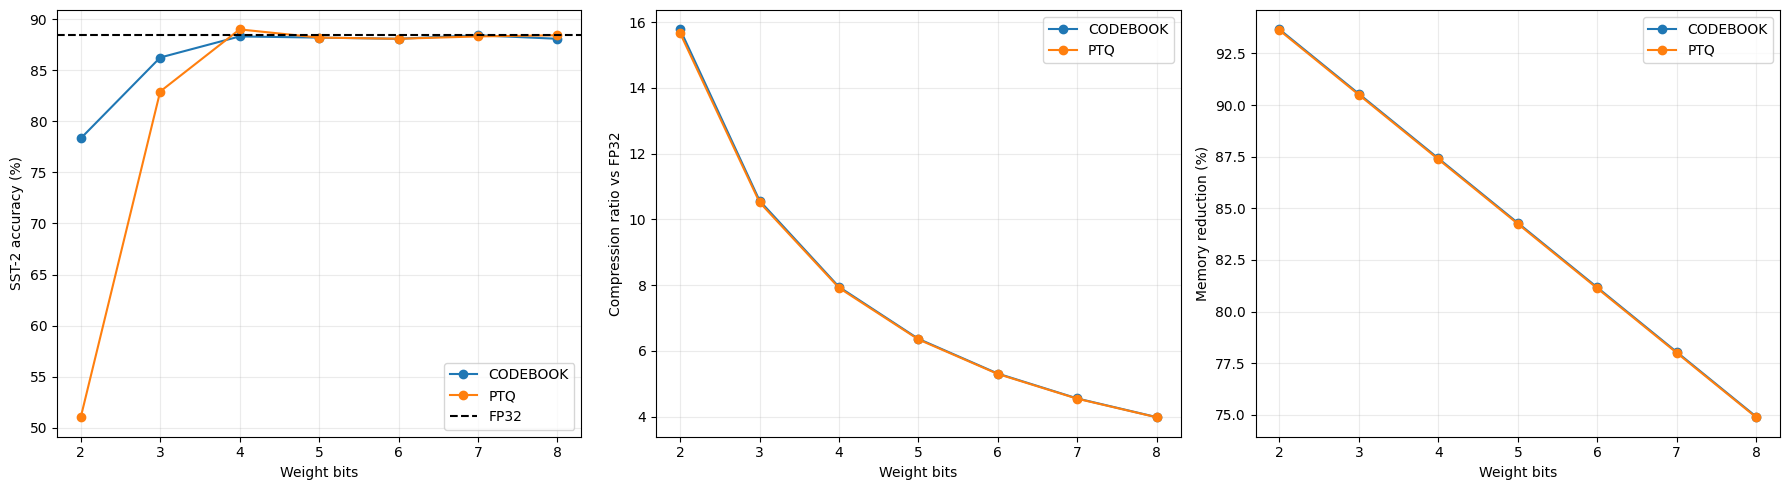

Saved under /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/distilbert_ptq_codebook_bit_sweep


In [7]:
accuracy_table=sweep.pivot(index="num_bits",columns="method",values="accuracy_percent"); compression_table=sweep.pivot(index="num_bits",columns="method",values="compression_ratio_vs_fp32")
display(accuracy_table); display(compression_table)
fig,axes=plt.subplots(1,3,figsize=(18,5))
for method,group in sweep.groupby("method"):
    group=group.sort_values("num_bits"); axes[0].plot(group.num_bits,group.accuracy_percent,"o-",label=method.upper())
    axes[1].plot(group.num_bits,group.compression_ratio_vs_fp32,"o-",label=method.upper())
    axes[2].plot(group.num_bits,group.memory_reduction_percent,"o-",label=method.upper())
axes[0].axhline(fp32_accuracy*100,color="black",linestyle="--",label="FP32")
axes[0].set_ylabel("SST-2 accuracy (%)"); axes[1].set_ylabel("Compression ratio vs FP32"); axes[2].set_ylabel("Memory reduction (%)")
for axis in axes: axis.set_xlabel("Weight bits"); axis.set_xticks(BIT_WIDTHS); axis.grid(alpha=.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "distilbert_ptq_codebook_2_to_8_bit.png",dpi=180,bbox_inches="tight"); plt.show()
coverage.to_csv(OUTPUT_DIR / "tensor_coverage.csv",index=False)
metadata={"model":str(MODEL_PATH),"dataset":"SST-2 complete labelled dev split","examples":NUM_EXAMPLES,"bits":BIT_WIDTHS,
    "methods":METHODS,"eligible_tensors":len(candidate_names),"activations_quantized":False,"fake_quantization":False,
    "storage":"theoretical packed assignments plus scales/codebooks and skipped FP32 tensors","fp32_accuracy_percent":fp32_accuracy*100,
    "tensorflow":tf.__version__,"keras":keras.__version__,"python":sys.version,"hardware":platform.platform()}
(OUTPUT_DIR / "results.json").write_text(json.dumps(metadata,indent=2,default=str)); print(f"Saved under {OUTPUT_DIR}")

## Interpretation

- Compare each row with the same FP32 model and all 872 examples.
- `num_bits` is the signed PTQ width or codebook assignment width; scalar codebook size is $K=2^b$.
- Negative accuracy drops are finite-sample variation, not evidence that quantization improves generalization.
- Storage is a representation estimate. Keras evaluation reconstructs weights and uses FP32 activations.